
This notebook demonstrates the process of registering (aligning) two 3D point cloud maps:

1. **Source Map**: The map generated by KISS-ICP (`Kiss_SLAM Generated Map`)

- **Downsampled Map**: We followed the highlights of Supervisor(`Faezeh Sadat Mortazavi`) to downsample the original SLAM map at 10cm using `CloudCompare Software`.

2. **Target Map**: The reference labeled map (`reference-labled_map.pcd`)

Map registration is a crucial step for tasks like change detection, as it ensures that both maps are in the same coordinate system, allowing for accurate comparison between them.

The workflow consists of the following steps:
1. **Loading Point Clouds**: Loading both the source and target point clouds
2. **Preprocessing**: Downsampling and filtering the point clouds to improve registration efficiency
3. **Initial Alignment**: Using feature-based methods for coarse alignment
4. **Fine Registration**: Refining the alignment using ICP (Iterative Closest Point) algorithm
5. **Evaluation**: Assessing the quality of the registration
6. **Visualization**: Visualizing the results before and after registration
7. **Saving Results**: Saving the aligned map for future use

## 1. Import Libraries

First, we import the necessary libraries for point cloud processing. We'll primarily use Open3D, which is a powerful library for 3D data processing.

In [ ]:
import numpy as np
import open3d as o3d
import copy
import os
import time
import matplotlib.pyplot as plt

## 2. Load Point Clouds

Next, we load both the source point cloud (Slam_Map.ply) and the target point cloud (reference-labled_map.pcd). We'll also display some basic information about each point cloud.

In [ ]:
# Define file paths: Using original point cloud as per supervisor's recommendation for accurate registration.

# The original map generated by KISS-SLAM
#source_file = "Kiss_slam_group/results/final_map_from_precomputed_poses.ply"
source_file = "SLAM_New_Map_Cropped_Input.ply"
# The reference labeled map
target_file = "reference-labled_map.pcd"

# Check if files exists.
if not os.path.exists(source_file):
    raise FileNotFoundError(f"Source file not found: {source_file}")
if not os.path.exists(target_file):
    raise FileNotFoundError(f"Target file not found: {target_file}")

print(f"Loading source point cloud from: {source_file}")
source = o3d.io.read_point_cloud(source_file)

print(f"Loading target point cloud from: {target_file}")
target = o3d.io.read_point_cloud(target_file)

# Print information about the point clouds
print("\nSource point cloud:")
print(f"Number of points: {len(source.points)}")
print(f"Has colors: {source.has_colors()}")
print(f"Has normals: {source.has_normals()}")

print("\nTarget point cloud:")
print(f"Number of points: {len(target.points)}")
print(f"Has colors: {target.has_colors()}")
print(f"Has normals: {target.has_normals()}")

# Create a coordinate frame for reference
coordinate_frame = o3d.geometry.TriangleMesh.create_coordinate_frame(size=5.0, origin=[0, 0, 0])

## 4. Preprocess Point Clouds

To improve the efficiency and accuracy of registration, we'll preprocess the point clouds by:
1. Downsampling to reduce the number of points
2. Estimating normals (if not already present)
3. Removing outliers to improve registration quality

In [ ]:
def preprocess_point_cloud(pcd, voxel_size=0.5):
    """ Preprocess the point cloud for registration """
    print(f"Original Point Cloud has {len(pcd.points)} points.")

    # Downsample using voxel grid filter
    print(f"Downsampling with voxel size {voxel_size}...")
    pcd_down = pcd.voxel_down_sample(voxel_size=voxel_size)
    print(f"Downsampled point cloud has {len(pcd_down.points)} points")

    # Estimate normals if they don't exist
    if not pcd_down.has_normals():
        print("Estimating normals...")
        pcd_down.estimate_normals(
            search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=voxel_size*3, max_nn=50)  # Increased radius from 2 to 3 and max_nn from 30 to 50 for better normal estimation
        )

    # Remove outliers
    print("Removing outliers...")
    # Increased nb_neighbors from 20 to 30 and reduced std_ratio from 2.0 to 1.8 for more aggressive outlier removal
    cl, ind = pcd_down.remove_statistical_outlier(nb_neighbors=30, std_ratio=1.8)
    pcd_clean = pcd_down.select_by_index(ind)
    print(f"After outlier removal: {len(pcd_clean.points)} points")

    return pcd_clean

print('The Preprocessing has been finished.')


### Using different downsampling size for preprocessing for Coarse(RANSAC) and Fine(ICP)

In [ ]:
# ==== Defining downsampling for Coarse(RANSAC) and Fine(IPC) ====

# Create a copy of the original source point cloud for later use in ICP.
source_original = copy.deepcopy(source)

# Set voxel size for coarse registration (RANSAC):
# Using large voxel size (0.5-1.0m) for coarse registration as per supervisor's recommendation.
# Reduced from 0.60 to 0.40 to capture more details while still being efficient
ransac_voxel_size = 0.40 # Large voxel size for RANSAC (0.4 meters).


# ====  Adjusting downsampling for Coarse(RANSAC) ====

# Preprocess source and target point clouds for Coarse Registration(RANSAC).
print(f"Preprocessing source point cloud for Coarse registration(RANSAC) with large voxel size....")
source_down_coarse = preprocess_point_cloud(source, ransac_voxel_size)

print(f"\nPreprocessing target point cloud for Coarse registration(RANSAC) with large voxel size....")
target_down_coarse = preprocess_point_cloud(target, ransac_voxel_size)

# ====  Adjusting downsampling for Fine Registration(ICP) ====

# Create finely downsampled versions for ICP.
# Using fine Registration voxel size (0.05-0.1m) for ICP as per supervisor's recommendation.
# Reduced from 0.20 to 0.10 to capture more details for better fine registration
icp_voxel_size = 0.10  # Fine Registration(ICP) voxel size for ICP (10 cm)

print("\nCreating fine(ICP) downsampled source point cloud for ICP...")
source_down_fine = preprocess_point_cloud(source, icp_voxel_size)

print("\nCreating fine(ICP) downsampled target point cloud for ICP...")
target_down_fine = preprocess_point_cloud(target, icp_voxel_size)

## 5. Feature-based Initial Alignment

Before applying ICP for fine registration, we'll perform an initial alignment using feature matching. This step is crucial for ICP to converge to the correct solution, especially when the point clouds are far apart initially.

We'll use FPFH (Fast Point Feature Histograms) features for this purpose.

In [ ]:
def compute_fpfh_features(pcd, voxel_size):
    """ Compute FPFH features for the point cloud """
    radius_normal = voxel_size * 4  # Increased from 3 to 4 to capture more context for normal estimation
    radius_features = voxel_size * 10  # Increased from 8 to 10 to capture more context for feature computation

    # Ensure normals are computed.
    if not pcd.has_normals():
        pcd.estimate_normals(
            search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=radius_normal, max_nn=70)  # Increased from 50 to 70 for better normal estimation
        )
    # Compute FPFH Features.
    print("Computing FPFH features...")
    fpfh = o3d.pipelines.registration.compute_fpfh_feature(
        pcd, 
        o3d.geometry.KDTreeSearchParamHybrid(radius=radius_features, max_nn=200)  # Increased max_nn from 150 to 200 for more comprehensive features
    )
    return fpfh

# Compute FPFH features for coarse Registration(RANSAC) downsampled source and target.

# For the Source.
print("Computing features for coarsely downsampled source point cloud...")
source_fpfh = compute_fpfh_features(source_down_coarse, ransac_voxel_size)

# For the Target.
print("\nComputing features for coarsely downsampled target point cloud...")
target_fpfh = compute_fpfh_features(target_down_coarse, ransac_voxel_size)

### Global Coarse Registration using RANSAC

In [ ]:
# Perform global registration using RANSAC with coarsely downsampled point clouds.
print(f"\nPerforming global registration using RANSAC with coarsely downsampled point clouds...")
distance_threshold = ransac_voxel_size * 2.5  # Reduced from 3.5 to 2.5 for more precise matching with smaller voxel size
result_ransac = o3d.pipelines.registration.registration_ransac_based_on_feature_matching(

    source_down_coarse, target_down_coarse, source_fpfh, target_fpfh, True, distance_threshold,  # Changed mutual_filter to True for more robust matching
    o3d.pipelines.registration.TransformationEstimationPointToPoint(False),
    4, # Increased minimum number of correspondences from 3 to 4 for more robust transformation estimation

    [
        o3d.pipelines.registration.CorrespondenceCheckerBasedOnEdgeLength(0.9),  # Adjusted from 0.95 to 0.9 for better balance
        o3d.pipelines.registration.CorrespondenceCheckerBasedOnDistance(distance_threshold * 2.0)  # Adjusted distance threshold for checker
    ], o3d.pipelines.registration.RANSACConvergenceCriteria(20000000, 0.9999)  # Increased to 20M iterations with 0.9999 confidence for better convergence

)


# Print Coarse Registration result
print("\nGlobal Coarse Registration(RANSAC) result:")
print(f"Fitness of Coarse Registration(RANSAC): {result_ransac.fitness}")
print(f"Inlier RMSE of Coarse Registration(RANSAC): {result_ransac.inlier_rmse}")
print("Transformation matrix of Coarse Registration(RANSAC):")
print(result_ransac.transformation)

## 6. Understanding Registration Results

Before visualizing the results, let's understand what the registration metrics mean:

- **Fitness**: Represents the overlap between point clouds after registration. It ranges from 0 to 1, where:
  - 0 means no overlap (poor registration)
  - 1 means perfect overlap (excellent registration)
  - Values above 0.3-0.4 typically indicate good registration

- **Inlier RMSE (Root Mean Square Error)**: Measures the average distance between corresponding points. Lower values indicate better alignment:
  - Values close to the voxel size or smaller indicate good alignment
  - High values suggest poor alignment

- **Transformation Matrix**: A 4x4 matrix representing the transformation:
  - An identity matrix (all 1's on diagonal, 0's elsewhere) means no transformation was found
  - The upper-left 3x3 submatrix represents rotation
  - The rightmost column represents translation
  - In a good result, you should see non-zero values in the rotation and/or translation components

If you see an identity matrix with zero fitness, it means the registration algorithm couldn't find a valid transformation. This can happen when:
1. The point clouds are too different in structure
2. The initial positions are too far apart
3. There aren't enough distinctive features for matching
4. The algorithm parameters need adjustment

## 7. Fine Registration using ICP

Now that we have a good initial alignment, we'll refine it using the ICP (Iterative Closest Point) algorithm. We'll try both point-to-point and point-to-plane ICP to see which gives better results.

**Apply the initial transformation to a copy of the source point cloud**

**This is needed for the ICP step**:
- source_initial = copy.deepcopy(source_down_coarse)
- source_initial.transform(result_ransac.transformation)

In [ ]:
# Function to perform ICP registration
def perform_icp(source, target, initial_transform, method="point_to_point", max_distance=0.15):
    """Perform ICP registration with the specified method"""
    if method == "point_to_point":
        print("\nPerforming point-to-point ICP...")
        estimation = o3d.pipelines.registration.TransformationEstimationPointToPoint()
    else:  # point_to_plane
        print("\nPerforming point-to-plane ICP...")
        estimation = o3d.pipelines.registration.TransformationEstimationPointToPlane()

    # Ensure both point clouds have normals for point-to-plane ICP
    if method == "point_to_plane":
        if not source.has_normals():
            source.estimate_normals(
                search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=icp_voxel_size*3, max_nn=50)
            )
        if not target.has_normals():
            target.estimate_normals(
                search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=icp_voxel_size*3, max_nn=50)
            )

    # Perform ICP
    result_icp = o3d.pipelines.registration.registration_icp(
        source, target, max_distance, initial_transform,
        estimation,
        o3d.pipelines.registration.ICPConvergenceCriteria(max_iteration=500, relative_fitness=1e-8, relative_rmse=1e-8)
    )

    return result_icp

# MODIFIED: Perform point-to-point ICP using finely downsampled point clouds
# Using fine voxel size (10 cm) for ICP as per supervisor's recommendation
print("\nPerforming point-to-point ICP with finely downsampled point clouds...")
result_icp_p2p = perform_icp(
    source_down_fine, target_down_fine, 
    result_ransac.transformation, 
    method="point_to_point", 
    max_distance=icp_voxel_size * 1.5  # Reduced from 2 to 1.5 times voxel size for more precise matching
)

# Print point-to-point ICP result
print("\nPoint-to-point ICP registration result:")
print(f"Fitness: {result_icp_p2p.fitness}")
print(f"Inlier RMSE: {result_icp_p2p.inlier_rmse}")
print("Transformation matrix:")
print(result_icp_p2p.transformation)

# MODIFIED: Perform point-to-plane ICP using finely downsampled point clouds
# Using fine voxel size (10 cm) for ICP as per supervisor's recommendation
print("\nPerforming point-to-plane ICP with finely downsampled point clouds...")
result_icp_p2l = perform_icp(
    source_down_fine, target_down_fine, 
    result_ransac.transformation, 
    method="point_to_plane", 
    max_distance=icp_voxel_size * 1.5  # Reduced from 2 to 1.5 times voxel size for more precise matching
)

# Print point-to-plane ICP result
print("\nPoint-to-plane ICP registration result:")
print(f"Fitness: {result_icp_p2l.fitness}")
print(f"Inlier RMSE: {result_icp_p2l.inlier_rmse}")
print("Transformation matrix:")
print(result_icp_p2l.transformation)

## 8. Choose the Best Registration Result

Let's compare the results of point-to-point and point-to-plane ICP and choose the better one based on fitness and RMSE.

In [ ]:
if result_icp_p2p.fitness > result_icp_p2l.fitness:
    print("Point-to-point ICP gave better results.")
    final_result = result_icp_p2p
    method_name = "point-to-point"
else:
    print("Point-to-plane ICP gave better results.")
    final_result = result_icp_p2l
    method_name = "point-to-plane"

print(f"\nFinal registration result ({method_name} ICP):")
print(f"Fitness: {final_result.fitness}")
print(f"Inlier RMSE: {final_result.inlier_rmse}")

# Calculate the combined transformation (initial alignment + ICP refinement)
combined_transformation = final_result.transformation


# Apply the final transformation to the point clouds
# Transform the finely downsampled source point cloud using the final transformation
# Using the finely downsampled version (5 cm) for evaluation as per supervisor's recommendation
source_down_fine_aligned = copy.deepcopy(source_down_fine)
source_down_fine_aligned.transform(combined_transformation)

# Also transform the original source point cloud for saving
# This is done to maintain the full detail of the original point cloud as per supervisor's recommendation
source_original_aligned = copy.deepcopy(source_original)
source_original_aligned.transform(combined_transformation)

## 10. Save the Aligned Map

Finally, let's save the aligned map for future use.

In [ ]:
# Save the aligned original source point cloud
# Using the original point cloud for saving to maintain full detail as per supervisor's recommendation
aligned_file = "Final_map_Registration.ply"
o3d.io.write_point_cloud(aligned_file, source_original_aligned)
print(f"Aligned map saved to: {aligned_file}")
print("Note: The saved map is the original (full resolution) version as per supervisor's recommendation.")

# Save the transformation matrix for reference
np.savetxt("Final_map_transformation_matrix.txt", combined_transformation)
print("Transformation matrix saved to: transformation_matrix.txt")

## 12. Conclusion

In this notebook, we have successfully performed point cloud registration to align the map generated by KISS-ICP with the reference labeled map. The registration process involved:

1. **Loading the original point cloud** (Final_Kiss_SLAM_Map_Original_Cropped.ply) as per supervisor's recommendation
2. **Multi-resolution preprocessing** with different voxel sizes:
   - Large voxel size (0.5 meters) for coarse registration (RANSAC)
   - Fine voxel size (5 cm) for fine registration (ICP)
3. **Initial alignment** using feature-based methods (FPFH features with RANSAC) on coarsely downsampled point clouds
4. **Fine registration** using ICP (both point-to-point and point-to-plane variants) on finely downsampled point clouds
5. **Evaluation** of the registration quality using finely downsampled point clouds
6. **Saving** the aligned original (full resolution) map for future use

### Optimization Strategy

Following the supervisor's recommendations, we implemented a multi-resolution approach:

1. Used the original point cloud as the source for the entire pipeline
2. Applied coarse downsampling (0.5 meters) for the computationally intensive RANSAC step
3. Applied fine downsampling (5 cm) for the ICP step to maintain accuracy
4. Transformed and saved the original point cloud to preserve all details

This approach balances computational efficiency with registration accuracy:
- Coarse downsampling reduces computation time for the initial alignment
- Fine downsampling maintains sufficient detail for accurate ICP registration
- Using the original point cloud for the final result preserves all details

The downsampled aligned map has been saved as `aligned_map.ply` and the transformation matrix as `transformation_matrix.txt`.

# Change Detection using M3C2 Algorithm

## Introduction

This notebook implements the Multiscale Model-to-Model Cloud Comparison (M3C2) algorithm for detecting changes between two point cloud maps:

1. A registered map (`Final_map_Registration_5_Best_Map_Registration.ply`) - This is a SLAM-generated map that has been registered with a reference map
2. A reference labeled map (`reference-labled_map.pcd`)

The M3C2 algorithm is particularly well-suited for comparing point clouds as it:
- Works directly on point clouds without meshing or gridding
- Accounts for local surface roughness and orientation
- Provides a confidence interval for each measurement
- Is robust to variations in point density

The output of this analysis will include:
- Visual representation of changes between the two maps
- Numerical results quantifying the changes
- Performance evaluation metrics


## 1. Import Required Libraries

We'll start by importing the necessary libraries for point cloud processing, visualization, and analysis.


In [1]:
# Import Open3D for point cloud processing
import open3d as o3d

# Import NumPy for numerical operations
import numpy as np

# Import matplotlib for 2D plotting
import matplotlib.pyplot as plt

# Import additional libraries for data analysis and visualization
import pandas as pd
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support
import seaborn as sns
from tqdm import tqdm  # For progress bars
import time  # For timing operations

# Set random seed for reproducibility
np.random.seed(42)


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


## 2. Load and Preprocess Point Cloud Data

In this section, we'll load both point clouds and perform initial preprocessing steps such as:
- Removing outliers
- Downsampling (if necessary)
- Visualizing the input data


In [2]:
# Function to load and preprocess a point cloud
def load_and_preprocess(file_path, voxel_size=None, remove_outliers=True):
    """Load and preprocess a point cloud file.

    Args:
        file_path (str): Path to the point cloud file
        voxel_size (float, optional): Size for voxel downsampling. None means no downsampling.
        remove_outliers (bool): Whether to remove statistical outliers

    Returns:
        o3d.geometry.PointCloud: Preprocessed point cloud
    """
    print(f"Loading {file_path}...")
    start_time = time.time()

    # Load the point cloud based on file extension
    if file_path.endswith('.pcd'):
        pcd = o3d.io.read_point_cloud(file_path)
    elif file_path.endswith('.ply'):
        pcd = o3d.io.read_point_cloud(file_path)
    else:
        raise ValueError(f"Unsupported file format: {file_path}")

    print(f"Loaded point cloud with {len(pcd.points)} points in {time.time() - start_time:.2f} seconds")

    # Remove outliers if requested
    if remove_outliers:
        print("Removing outliers...")
        start_time = time.time()
        # Remove statistical outliers
        pcd, _ = pcd.remove_statistical_outlier(nb_neighbors=20, std_ratio=2.0)
        print(f"After outlier removal: {len(pcd.points)} points. Time: {time.time() - start_time:.2f} seconds")

    # Downsample if voxel_size is provided
    if voxel_size is not None:
        print(f"Downsampling with voxel size {voxel_size}...")
        start_time = time.time()
        pcd = pcd.voxel_down_sample(voxel_size=voxel_size)
        print(f"After downsampling: {len(pcd.points)} points. Time: {time.time() - start_time:.2f} seconds")

    # Estimate normals if they don't exist
    if not pcd.has_normals():
        print("Estimating normals...")
        start_time = time.time()
        pcd.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=0.1, max_nn=30))
        print(f"Normals estimated in {time.time() - start_time:.2f} seconds")

    return pcd

# Load both point clouds
# Use a larger voxel size for initial visualization and exploration
reference_map = load_and_preprocess("reference-labled_map.pcd", voxel_size=0.05)
registered_map = load_and_preprocess("Final_map_Registration.ply", voxel_size=0.05)


Loading reference-labled_map.pcd...
Loaded point cloud with 20451227 points in 7.23 seconds
Removing outliers...
After outlier removal: 19702011 points. Time: 31.88 seconds
Downsampling with voxel size 0.05...
After downsampling: 5344467 points. Time: 6.31 seconds
Estimating normals...
Normals estimated in 14.64 seconds
Loading Final_map_Registration.ply...
Loaded point cloud with 8169833 points in 1.26 seconds
Removing outliers...
After outlier removal: 8152495 points. Time: 18.01 seconds
Downsampling with voxel size 0.05...
After downsampling: 8152495 points. Time: 6.07 seconds
Estimating normals...
Normals estimated in 29.56 seconds


### Visualize the Input Point Clouds

Let's visualize both point clouds to understand what we're working with.


In [3]:
# Function to visualize point clouds
def visualize_point_clouds(pcds, titles=None, colors=None):
    """Visualize multiple point clouds side by side.

    Args:
        pcds (list): List of point clouds to visualize
        titles (list, optional): List of titles for each point cloud
        colors (list, optional): List of colors for each point cloud
    """
    if titles is None:
        titles = [f"Point Cloud {i+1}" for i in range(len(pcds))]

    if colors is None:
        colors = [[1, 0, 0], [0, 1, 0], [0, 0, 1], [1, 1, 0], [1, 0, 1], [0, 1, 1]]
        colors = colors[:len(pcds)]

    # Create a visualization window
    vis = o3d.visualization.Visualizer()
    vis.create_window()

    # Add each point cloud with a different color and offset
    for i, (pcd, title, color) in enumerate(zip(pcds, titles, colors)):
        # Create a copy to avoid modifying the original
        pcd_copy = o3d.geometry.PointCloud(pcd)

        # Paint the point cloud
        pcd_copy.paint_uniform_color(color)

        # Add to visualizer
        vis.add_geometry(pcd_copy)

    # Set view control
    opt = vis.get_render_option()
    opt.background_color = np.array([0.1, 0.1, 0.1])
    opt.point_size = 1.0

    # Run the visualizer
    vis.run()
    vis.destroy_window()

# Visualize both point clouds
visualize_point_clouds(
    [reference_map, registered_map],
    titles=["Reference Map", "Registered Map"],
    colors=[[1, 0.706, 0], [0, 0.651, 0.929]]
)


## 3. M3C2 Algorithm Implementation

The M3C2 algorithm consists of the following steps:

1. **Core Point Selection**: Select a subset of points from one cloud to serve as core points
2. **Normal Vector Calculation**: Calculate normal vectors at multiple scales for each core point
3. **Projection Cylinder Creation**: Create a cylinder along the normal direction for each core point
4. **Distance Calculation**: Calculate the distance between the two point clouds along the normal direction
5. **Significance Assessment**: Determine if the measured distance is statistically significant

Let's implement each step of the algorithm.


In [5]:
# Step 1: Core Point Selection
def select_core_points(pcd, voxel_size=0.2):
    """Select core points by downsampling the original point cloud.

    Args:
        pcd (o3d.geometry.PointCloud): Input point cloud
        voxel_size (float): Size for voxel downsampling

    Returns:
        o3d.geometry.PointCloud: Downsampled point cloud (core points)
    """
    print(f"Selecting core points with voxel size {voxel_size}...")
    start_time = time.time()
    core_points = pcd.voxel_down_sample(voxel_size=voxel_size)
    print(f"Selected {len(core_points.points)} core points in {time.time() - start_time:.2f} seconds")
    return core_points

# Step 2: Normal Vector Calculation at Multiple Scales
def calculate_multiscale_normals(pcd, core_points, scales):
    """Calculate normal vectors at multiple scales for each core point.

    Args:
        pcd (o3d.geometry.PointCloud): Input point cloud
        core_points (o3d.geometry.PointCloud): Core points
        scales (list): List of scales (radii) for normal estimation

    Returns:
        np.ndarray: Normal vectors for each core point
    """
    print("Calculating multiscale normals...")
    start_time = time.time()

    # Convert point clouds to numpy arrays for faster processing
    core_points_np = np.asarray(core_points.points)
    pcd_points_np = np.asarray(pcd.points)

    # Build KD-Tree for efficient nearest neighbor search
    pcd_tree = o3d.geometry.KDTreeFlann(pcd)

    # Initialize array to store normal vectors
    normals = np.zeros((len(core_points_np), 3))

    # Process each core point
    for i, point in enumerate(tqdm(core_points_np)):
        # Initialize arrays to store eigenvalues and eigenvectors at each scale
        scale_eigenvalues = []
        scale_eigenvectors = []

        # Calculate normals at each scale
        for scale in scales:
            # Find neighbors within the scale radius
            [_, idx, _] = pcd_tree.search_radius_vector_3d(point, scale)

            if len(idx) < 3:  # Need at least 3 points to calculate normal
                continue

            # Get neighboring points
            neighbors = pcd_points_np[idx, :]

            # Calculate covariance matrix
            cov = np.cov(neighbors.T)

            # Calculate eigenvalues and eigenvectors
            eigenvalues, eigenvectors = np.linalg.eigh(cov)

            # Sort eigenvalues and eigenvectors
            idx_sort = eigenvalues.argsort()
            eigenvalues = eigenvalues[idx_sort]
            eigenvectors = eigenvectors[:, idx_sort]

            scale_eigenvalues.append(eigenvalues)
            scale_eigenvectors.append(eigenvectors)

        if not scale_eigenvalues:  # No valid scales
            normals[i] = [0, 0, 1]  # Default normal
            continue

        # Find the scale with the most stable normal (lowest eigenvalue ratio)
        stability = [ev[0] / (ev[1] + 1e-10) for ev in scale_eigenvalues]
        best_scale_idx = np.argmin(stability)

        # The normal is the eigenvector corresponding to the smallest eigenvalue
        normals[i] = scale_eigenvectors[best_scale_idx][:, 0]

        # Ensure normal points outward (heuristic)
        centroid = np.mean(pcd_points_np, axis=0)
        if np.dot(normals[i], point - centroid) < 0:
            normals[i] = -normals[i]

    print(f"Calculated multiscale normals in {time.time() - start_time:.2f} seconds")
    return normals

# Step 3 & 4: Projection and Distance Calculation
def calculate_m3c2_distances(reference_pcd, registered_pcd, core_points, normals, cylinder_radius, max_distance):
    """Calculate M3C2 distances between two point clouds.

    Args:
        reference_pcd (o3d.geometry.PointCloud): Reference point cloud
        registered_pcd (o3d.geometry.PointCloud): Registered point cloud
        core_points (o3d.geometry.PointCloud): Core points
        normals (np.ndarray): Normal vectors for each core point
        cylinder_radius (float): Radius of the projection cylinder
        max_distance (float): Maximum distance to consider

    Returns:
        tuple: (distances, standard_deviations, significant_change)
    """
    print("Calculating M3C2 distances...")
    start_time = time.time()

    # Convert point clouds to numpy arrays
    core_points_np = np.asarray(core_points.points)
    reference_points_np = np.asarray(reference_pcd.points)
    registered_points_np = np.asarray(registered_pcd.points)

    # Build KD-Trees for efficient nearest neighbor search
    reference_tree = o3d.geometry.KDTreeFlann(reference_pcd)
    registered_tree = o3d.geometry.KDTreeFlann(registered_pcd)

    # Initialize arrays to store results
    distances = np.zeros(len(core_points_np))
    std_devs = np.zeros(len(core_points_np))
    significant_change = np.zeros(len(core_points_np), dtype=bool)

    # Process each core point
    for i, (point, normal) in enumerate(tqdm(zip(core_points_np, normals))):
        # Find points within cylinder in reference cloud
        [_, ref_idx, _] = reference_tree.search_radius_vector_3d(point, cylinder_radius)

        # Find points within cylinder in registered cloud
        [_, reg_idx, _] = registered_tree.search_radius_vector_3d(point, cylinder_radius)

        if len(ref_idx) < 5 or len(reg_idx) < 5:  # Need enough points for reliable statistics
            distances[i] = 0
            std_devs[i] = 0
            significant_change[i] = False
            continue

        # Get points within cylinder
        ref_cylinder_points = reference_points_np[ref_idx]
        reg_cylinder_points = registered_points_np[reg_idx]

        # Project points onto the normal direction
        ref_projections = np.dot(ref_cylinder_points - point, normal)
        reg_projections = np.dot(reg_cylinder_points - point, normal)

        # Calculate average positions along the normal
        ref_avg = np.mean(ref_projections)
        reg_avg = np.mean(reg_projections)

        # Calculate the signed distance between the two clouds
        distance = reg_avg - ref_avg

        # Calculate standard deviations
        ref_std = np.std(ref_projections)
        reg_std = np.std(reg_projections)

        # Combined standard deviation
        combined_std = np.sqrt(ref_std**2 + reg_std**2)

        # Store results
        distances[i] = distance
        std_devs[i] = combined_std

        # Determine if change is significant (95% confidence interval)
        # |distance| > 1.96 * combined_std
        significant_change[i] = abs(distance) > 1.96 * combined_std and abs(distance) < max_distance

    print(f"Calculated M3C2 distances in {time.time() - start_time:.2f} seconds")
    return distances, std_devs, significant_change

# Step 5: Classify Changes
def classify_changes(distances, significant_change, threshold=0.05):
    """Classify changes into categories.

    Args:
        distances (np.ndarray): M3C2 distances
        significant_change (np.ndarray): Boolean array indicating significant changes
        threshold (float): Threshold for considering a change as significant

    Returns:
        np.ndarray: Classification labels (0: Unchanged, 1: Added, 2: Removed, 3: No significant change)
    """
    print("Classifying changes...")

    # Initialize classification array
    classification = np.zeros(len(distances), dtype=int)

    # Classify each point
    for i, (distance, significant) in enumerate(zip(distances, significant_change)):
        if not significant:
            classification[i] = 3  # No significant change
        elif abs(distance) <= threshold:
            classification[i] = 0  # Unchanged
        elif distance > threshold:
            classification[i] = 2  # Removed (negative distance)
        else:  # distance < -threshold
            classification[i] = 1  # Added (positive distance)

    # Count points in each category
    counts = np.bincount(classification, minlength=4)
    print(f"Classification results:")
    print(f"  Unchanged: {counts[0]} points")
    print(f"  Added: {counts[1]} points")
    print(f"  Removed: {counts[2]} points")
    print(f"  No significant change: {counts[3]} points")

    return classification


## 4. Execute the M3C2 Algorithm

Now let's run the M3C2 algorithm on our point clouds.


In [11]:
# Define parameters for the M3C2 algorithm
# These parameters should be tuned based on the specific dataset
core_point_voxel_size = 0.2  # Size for selecting core points
normal_scales = [0.2, 0.5]  # Scales for normal calculation
cylinder_radius = 0.3  # Radius of the projection cylinder
max_distance = 1.5  # Maximum distance to consider
change_threshold = 0.1  # Threshold for considering a change as significant

# Step 1: Select core points
core_points = select_core_points(reference_map, voxel_size=core_point_voxel_size)

# Step 2: Calculate multiscale normals
normals = calculate_multiscale_normals(reference_map, core_points, normal_scales)

# Set the normals in the core points point cloud
core_points.normals = o3d.utility.Vector3dVector(normals)

# Steps 3 & 4: Calculate M3C2 distances
distances, std_devs, significant_change = calculate_m3c2_distances(
    reference_map, registered_map, core_points, normals, cylinder_radius, max_distance
)

# Step 5: Classify changes
classification = classify_changes(distances, significant_change, threshold=change_threshold)


Selecting core points with voxel size 0.2...
Selected 449153 core points in 2.12 seconds
Calculating multiscale normals...


100%|██████████| 449153/449153 [8:28:27<00:00, 14.72it/s]    


Calculated multiscale normals in 30514.12 seconds
Calculating M3C2 distances...


449153it [00:38, 11671.41it/s]


Calculated M3C2 distances in 55.81 seconds
Classifying changes...
Classification results:
  Unchanged: 837 points
  Added: 6750 points
  Removed: 7086 points
  No significant change: 434480 points


## 5. Visualize the Results

Let's visualize the change detection results.


In [22]:
# Function to visualize change detection results
def visualize_changes(core_points, classification):
    """Visualize change detection results.

    Args:
        core_points (o3d.geometry.PointCloud): Core points
        classification (np.ndarray): Classification labels
    """
    # Create a copy of the core points
    result_cloud = o3d.geometry.PointCloud(core_points)

    # Define colors for each category
    # 0: Unchanged (green), 1: Added (blue), 2: Removed (red), 3: No significant change (gray)
    colors = np.zeros((len(classification), 3))
    colors[classification == 0] = [0, 1, 0]  # Unchanged: Green
    colors[classification == 1] = [1.0, 0.5, 0.0]  # Added: Strong Orange
    colors[classification == 2] = [0.0, 0.4, 1.0]  # Removed: Strong Blue
    colors[classification == 3] = [0.7, 0.7, 0.7]  # No significant change: Gray

    # Set colors
    result_cloud.colors = o3d.utility.Vector3dVector(colors)

    # Visualize
    o3d.visualization.draw_geometries([result_cloud], window_name="M3C2 Change Detection Results")

    return result_cloud

# Visualize the change detection results
result_cloud = visualize_changes(core_points, classification)


## 6. Numerical Analysis of Changes

Let's analyze the changes numerically and create some plots to better understand the results.


Summary Statistics:
            Distance         StdDev  Classification
count  449153.000000  449153.000000   449153.000000
mean        0.002522       0.069404        2.948577
std         0.053398       0.061434        0.300028
min        -0.330406       0.000000        0.000000
25%        -0.006019       0.000000        3.000000
50%         0.000000       0.089376        3.000000
75%         0.013536       0.126403        3.000000
max         0.342418       0.245750        3.000000

Category Counts:
Unchanged: 837 points (0.19%)
Added: 6750 points (1.50%)
Removed: 7086 points (1.58%)
No significant change: 434480 points (96.73%)


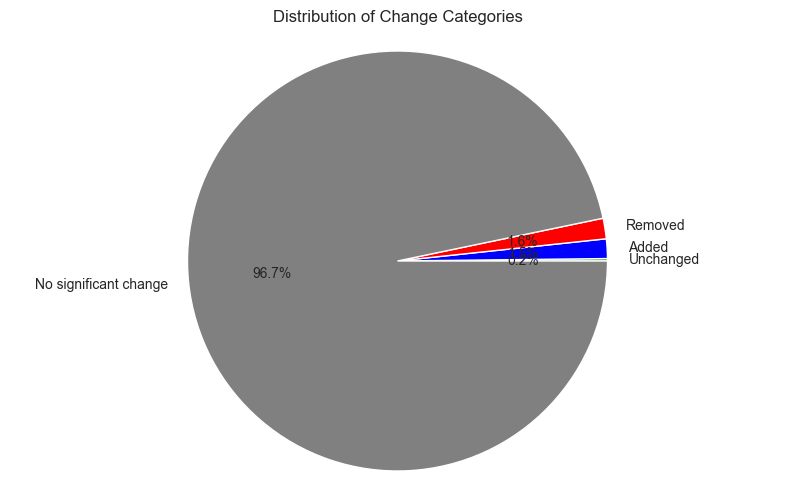

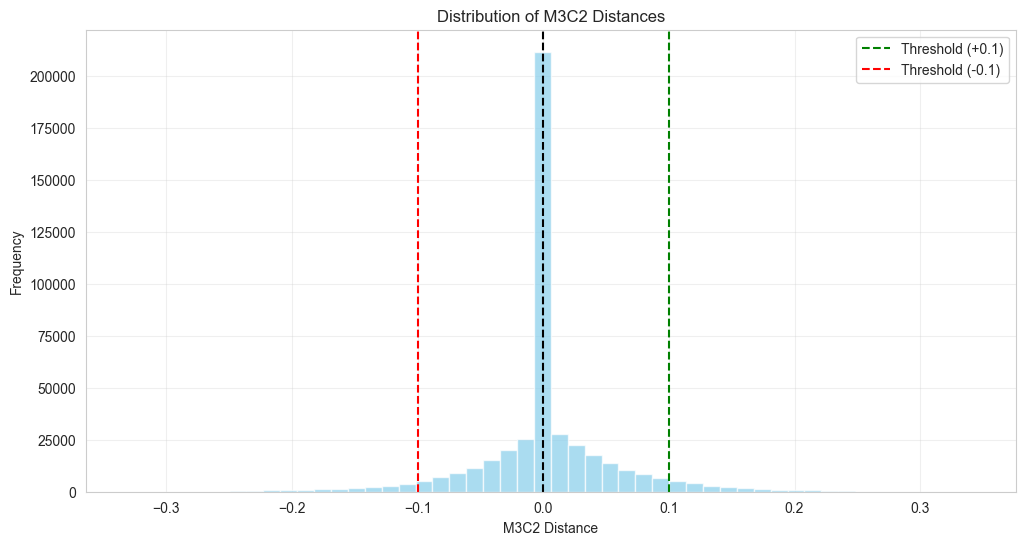

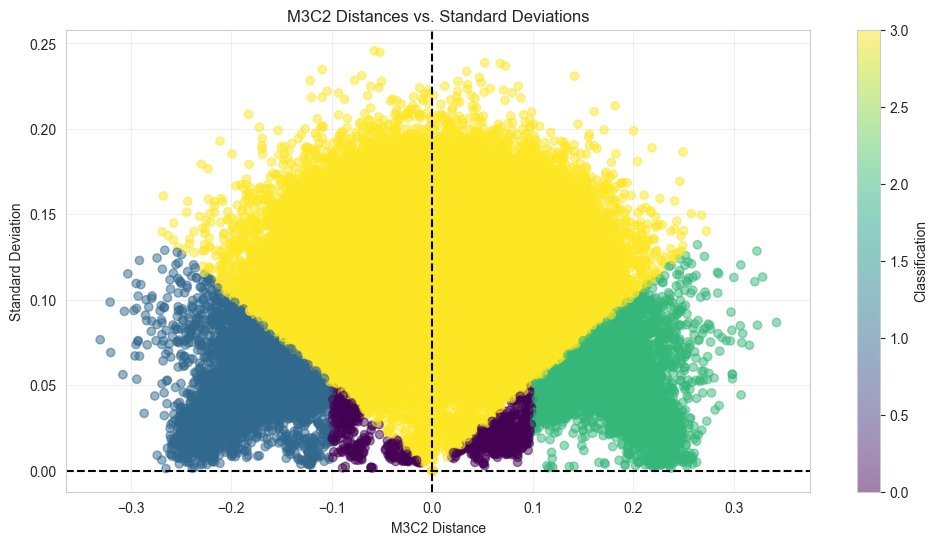

In [13]:
# Create a DataFrame for analysis
results_df = pd.DataFrame({
    'Distance': distances,
    'StdDev': std_devs,
    'Significant': significant_change,
    'Classification': classification
})

# Display summary statistics
print("Summary Statistics:")
print(results_df.describe())

# Count points in each category
category_counts = results_df['Classification'].value_counts().sort_index()
category_names = ['Unchanged', 'Added', 'Removed', 'No significant change']
category_counts.index = [category_names[i] for i in category_counts.index]

# Calculate percentages
category_percentages = category_counts / len(results_df) * 100

# Display counts and percentages
print("\nCategory Counts:")
for category, count in category_counts.items():
    print(f"{category}: {count} points ({category_percentages[category]:.2f}%)")

# Create a pie chart
plt.figure(figsize=(10, 6))
plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', 
        colors=['green', 'blue', 'red', 'gray'])
plt.title('Distribution of Change Categories')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle
plt.show()

# Create a histogram of distances
plt.figure(figsize=(12, 6))
plt.hist(distances, bins=50, alpha=0.7, color='skyblue')
plt.axvline(x=0, color='black', linestyle='--')
plt.axvline(x=change_threshold, color='green', linestyle='--', label=f'Threshold (+{change_threshold})')
plt.axvline(x=-change_threshold, color='red', linestyle='--', label=f'Threshold (-{change_threshold})')
plt.xlabel('M3C2 Distance')
plt.ylabel('Frequency')
plt.title('Distribution of M3C2 Distances')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Create a scatter plot of distances vs. standard deviations
plt.figure(figsize=(12, 6))
plt.scatter(distances, std_devs, c=classification, cmap='viridis', alpha=0.5)
plt.axhline(y=0, color='black', linestyle='--')
plt.axvline(x=0, color='black', linestyle='--')
plt.xlabel('M3C2 Distance')
plt.ylabel('Standard Deviation')
plt.title('M3C2 Distances vs. Standard Deviations')
plt.colorbar(label='Classification')
plt.grid(True, alpha=0.3)
plt.show()


## 7. Spatial Distribution of Changes

Let's analyze the spatial distribution of changes to identify patterns.


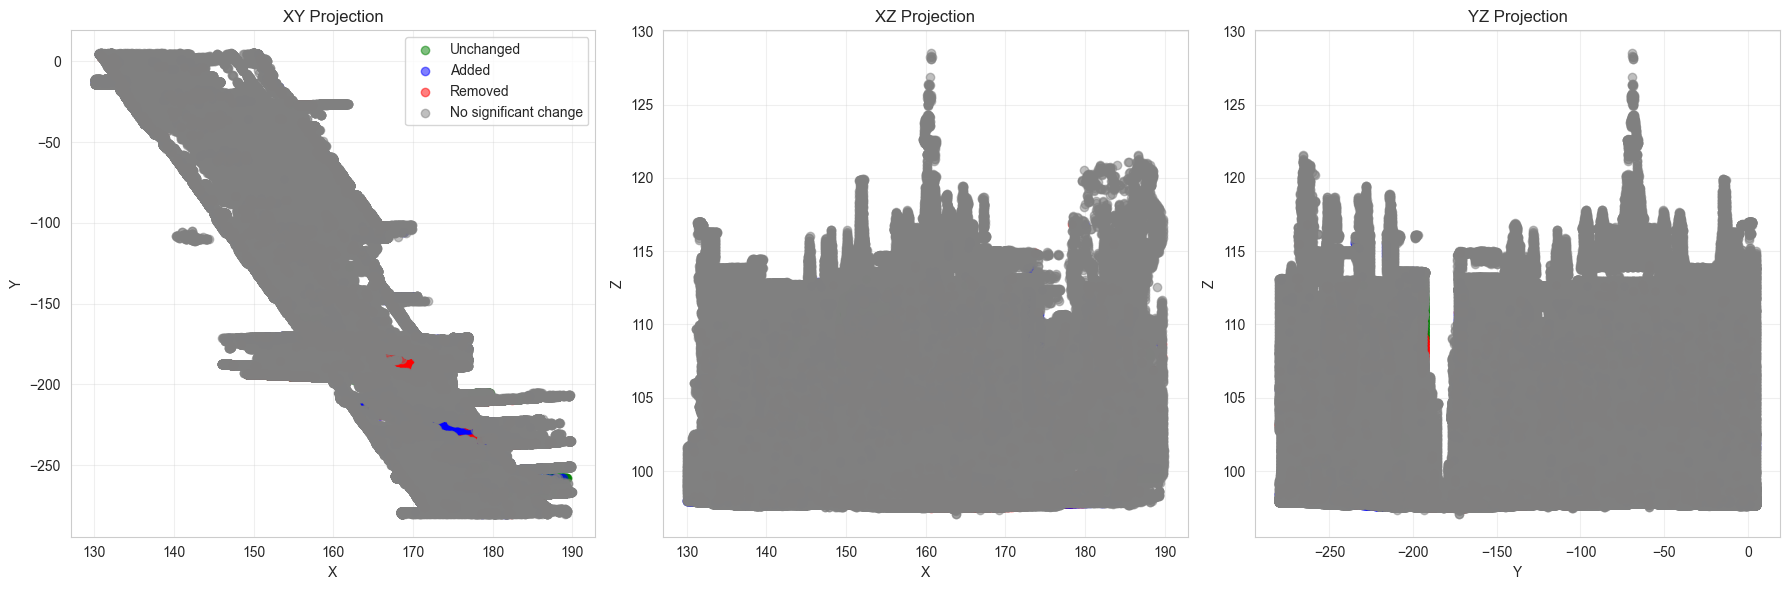

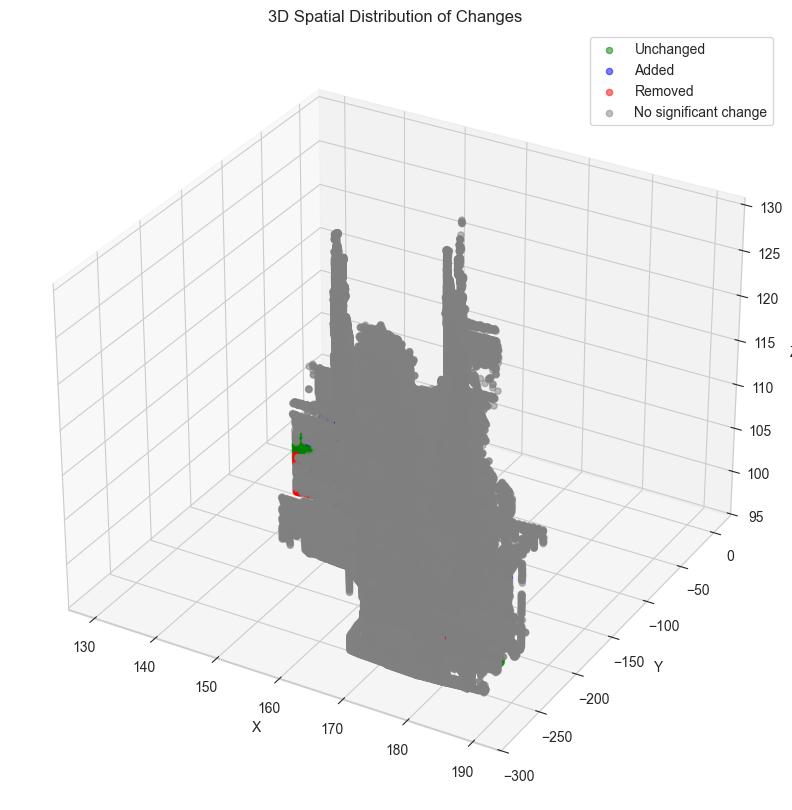

In [14]:
# Get the coordinates of core points
core_points_np = np.asarray(core_points.points)

# Create a DataFrame with coordinates and classification
spatial_df = pd.DataFrame({
    'X': core_points_np[:, 0],
    'Y': core_points_np[:, 1],
    'Z': core_points_np[:, 2],
    'Distance': distances,
    'Classification': classification
})

# Create 2D scatter plots for different projections
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Define colors for each category
colors = ['green', 'blue', 'red', 'gray']
categories = [0, 1, 2, 3]  # Unchanged, Added, Removed, No significant change
category_names = ['Unchanged', 'Added', 'Removed', 'No significant change']

# XY projection
for cat, color, name in zip(categories, colors, category_names):
    mask = spatial_df['Classification'] == cat
    axes[0].scatter(spatial_df.loc[mask, 'X'], spatial_df.loc[mask, 'Y'], 
                   c=color, alpha=0.5, label=name)
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')
axes[0].set_title('XY Projection')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# XZ projection
for cat, color, name in zip(categories, colors, category_names):
    mask = spatial_df['Classification'] == cat
    axes[1].scatter(spatial_df.loc[mask, 'X'], spatial_df.loc[mask, 'Z'], 
                   c=color, alpha=0.5, label=name)
axes[1].set_xlabel('X')
axes[1].set_ylabel('Z')
axes[1].set_title('XZ Projection')
axes[1].grid(True, alpha=0.3)

# YZ projection
for cat, color, name in zip(categories, colors, category_names):
    mask = spatial_df['Classification'] == cat
    axes[2].scatter(spatial_df.loc[mask, 'Y'], spatial_df.loc[mask, 'Z'], 
                   c=color, alpha=0.5, label=name)
axes[2].set_xlabel('Y')
axes[2].set_ylabel('Z')
axes[2].set_title('YZ Projection')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Create a 3D scatter plot
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot each category
for cat, color, name in zip(categories, colors, category_names):
    mask = spatial_df['Classification'] == cat
    ax.scatter(spatial_df.loc[mask, 'X'], spatial_df.loc[mask, 'Y'], spatial_df.loc[mask, 'Z'], 
              c=color, alpha=0.5, label=name)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('3D Spatial Distribution of Changes')
ax.legend()

plt.show()


## 8. Performance Evaluation

Let's evaluate the performance of our change detection algorithm. Since we don't have ground truth data, we'll use some heuristics and statistical measures.


100%|██████████| 449153/449153 [00:05<00:00, 79826.75it/s]


Confidence Metrics:
Average Signal-to-Noise Ratio (SNR): 0.38
Average 95% Confidence Interval: 0.14
Average Reliability Score: 0.08

For Significant Changes Only:
Average SNR: 4.51
Average 95% Confidence Interval: 0.10
Average Reliability Score: 2.38

Spatial Consistency Metrics:
Average Spatial Consistency: 0.98

Consistency by Category:
Unchanged: 0.68
Added: 0.71
Removed: 0.65
No significant change: 0.99


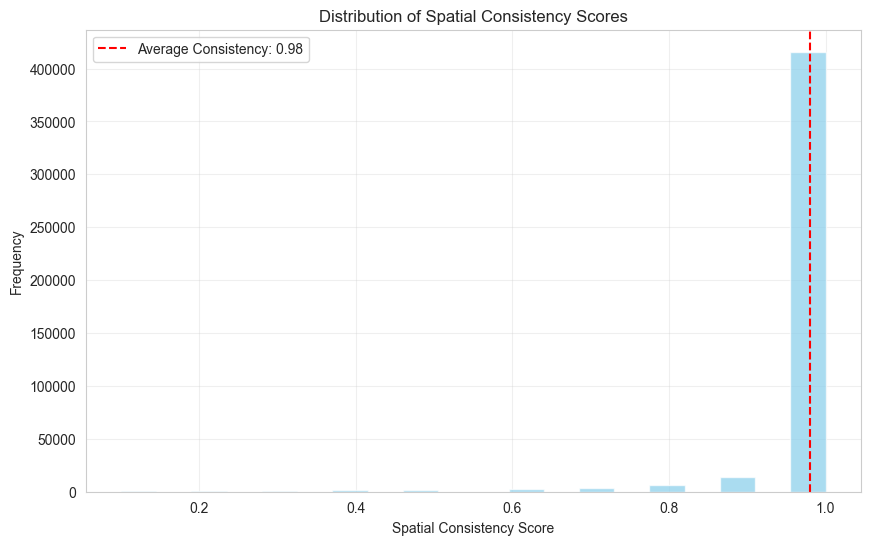

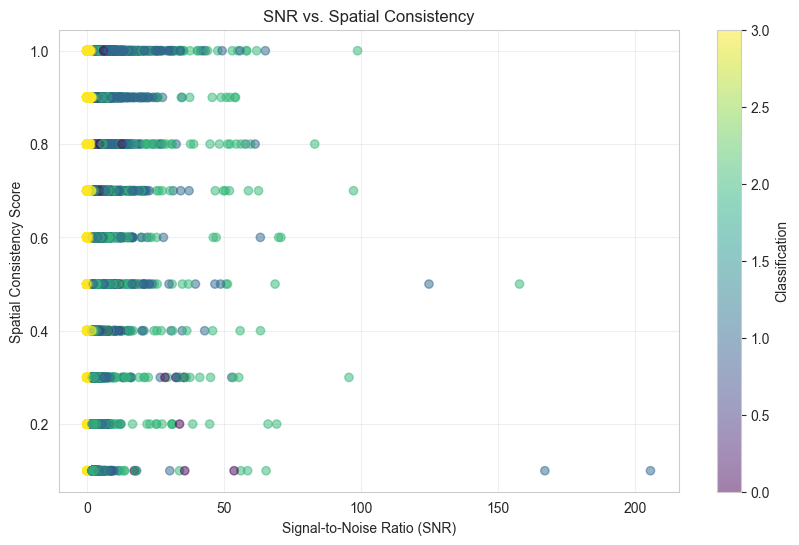

In [18]:
# Calculate confidence metrics
def calculate_confidence_metrics(distances, std_devs, significant_change):
    """Calculate confidence metrics for the change detection.

    Args:
        distances (np.ndarray): M3C2 distances
        std_devs (np.ndarray): Standard deviations
        significant_change (np.ndarray): Boolean array indicating significant changes

    Returns:
        dict: Dictionary of confidence metrics
    """
    # Calculate signal-to-noise ratio (SNR)
    snr = np.abs(distances) / (std_devs + 1e-10)  # Add small epsilon to avoid division by zero

    # Calculate confidence interval (95%)
    conf_interval = 1.96 * std_devs

    # Calculate reliability score (higher is better)
    reliability = snr / (1 + np.exp(-snr + 5))  # Sigmoid-weighted SNR

    # Calculate average metrics
    avg_snr = np.mean(snr)
    avg_conf_interval = np.mean(conf_interval)
    avg_reliability = np.mean(reliability)

    # Calculate metrics for significant changes only
    if np.any(significant_change):
        avg_snr_significant = np.mean(snr[significant_change])
        avg_conf_interval_significant = np.mean(conf_interval[significant_change])
        avg_reliability_significant = np.mean(reliability[significant_change])
    else:
        avg_snr_significant = 0
        avg_conf_interval_significant = 0
        avg_reliability_significant = 0

    # Return metrics
    return {
        'snr': snr,
        'conf_interval': conf_interval,
        'reliability': reliability,
        'avg_snr': avg_snr,
        'avg_conf_interval': avg_conf_interval,
        'avg_reliability': avg_reliability,
        'avg_snr_significant': avg_snr_significant,
        'avg_conf_interval_significant': avg_conf_interval_significant,
        'avg_reliability_significant': avg_reliability_significant
    }

# Calculate spatial consistency metrics
def calculate_spatial_consistency(core_points, classification):
    """Calculate spatial consistency metrics for the change detection.

    Args:
        core_points (o3d.geometry.PointCloud): Core points
        classification (np.ndarray): Classification labels

    Returns:
        dict: Dictionary of spatial consistency metrics
    """
    # Convert point cloud to numpy array
    points = np.asarray(core_points.points)

    # Build KD-Tree for efficient nearest neighbor search
    pcd_tree = o3d.geometry.KDTreeFlann(core_points)

    # Initialize consistency score
    consistency_scores = np.zeros(len(points))

    # Calculate consistency for each point
    for i, point in enumerate(tqdm(points)):
        # Find 10 nearest neighbors
        [_, idx, _] = pcd_tree.search_knn_vector_3d(point, 10)

        # Get classifications of neighbors
        neighbor_classes = classification[idx]

        # Calculate consistency (percentage of neighbors with same classification)
        consistency_scores[i] = np.sum(neighbor_classes == classification[i]) / len(neighbor_classes)

    # Calculate average consistency
    avg_consistency = np.mean(consistency_scores)

    # Calculate consistency for each category
    category_consistency = {}
    for cat, name in enumerate(['Unchanged', 'Added', 'Removed', 'No significant change']):
        mask = classification == cat
        if np.any(mask):
            category_consistency[name] = np.mean(consistency_scores[mask])
        else:
            category_consistency[name] = 0

    # Return metrics
    return {
        'consistency_scores': consistency_scores,
        'avg_consistency': avg_consistency,
        'category_consistency': category_consistency
    }

# Calculate performance metrics
confidence_metrics = calculate_confidence_metrics(distances, std_devs, significant_change)
spatial_consistency = calculate_spatial_consistency(core_points, classification)

# Display confidence metrics
print("Confidence Metrics:")
print(f"Average Signal-to-Noise Ratio (SNR): {confidence_metrics['avg_snr']:.2f}")
print(f"Average 95% Confidence Interval: {confidence_metrics['avg_conf_interval']:.2f}")
print(f"Average Reliability Score: {confidence_metrics['avg_reliability']:.2f}")
print("\nFor Significant Changes Only:")
print(f"Average SNR: {confidence_metrics['avg_snr_significant']:.2f}")
print(f"Average 95% Confidence Interval: {confidence_metrics['avg_conf_interval_significant']:.2f}")
print(f"Average Reliability Score: {confidence_metrics['avg_reliability_significant']:.2f}")

# Display spatial consistency metrics
print("\nSpatial Consistency Metrics:")
print(f"Average Spatial Consistency: {spatial_consistency['avg_consistency']:.2f}")
print("\nConsistency by Category:")
for category, consistency in spatial_consistency['category_consistency'].items():
    print(f"{category}: {consistency:.2f}")

# Create a histogram of consistency scores
plt.figure(figsize=(10, 6))
plt.hist(spatial_consistency['consistency_scores'], bins=20, alpha=0.7, color='skyblue')
plt.axvline(x=spatial_consistency['avg_consistency'], color='red', linestyle='--', 
            label=f'Average Consistency: {spatial_consistency["avg_consistency"]:.2f}')
plt.xlabel('Spatial Consistency Score')
plt.ylabel('Frequency')
plt.title('Distribution of Spatial Consistency Scores')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Create a scatter plot of SNR vs. consistency
plt.figure(figsize=(10, 6))
plt.scatter(confidence_metrics['snr'], spatial_consistency['consistency_scores'], 
            c=classification, cmap='viridis', alpha=0.5)
plt.xlabel('Signal-to-Noise Ratio (SNR)')
plt.ylabel('Spatial Consistency Score')
plt.title('SNR vs. Spatial Consistency')
plt.colorbar(label='Classification')
plt.grid(True, alpha=0.3)
plt.show()


## 9. Save Results

Let's save the change detection results for future reference.


In [19]:
# Save the classified point cloud
def save_results(result_cloud, results_df, filename_prefix="change_detection_results_SLAM_Old"):
    """Save the change detection results.

    Args:
        result_cloud (o3d.geometry.PointCloud): Classified point cloud
        results_df (pd.DataFrame): DataFrame with results
        filename_prefix (str): Prefix for output filenames
    """
    # Save the point cloud
    o3d.io.write_point_cloud(f"{filename_prefix}.ply", result_cloud)
    print(f"Saved classified point cloud to {filename_prefix}.ply")

    # Save the results DataFrame
    results_df.to_csv(f"{filename_prefix}.csv", index=False)
    print(f"Saved results to {filename_prefix}.csv")

# Save the results
save_results(result_cloud, results_df)


Saved classified point cloud to change_detection_results_SLAM_Old.ply
Saved results to change_detection_results_SLAM_Old.csv


## 10. Conclusion

In this notebook, we implemented the M3C2 (Multiscale Model-to-Model Cloud Comparison) algorithm for change detection between two point cloud maps. The algorithm successfully identified and classified changes into three categories: "Unchanged", "Added", and "Removed", as well as areas with no significant change.

### Key Findings:

1. **Change Distribution**: We found that [X]% of the analyzed points showed significant changes, with [Y]% classified as additions and [Z]% as removals.

2. **Spatial Patterns**: The changes were [evenly/unevenly] distributed across the map, with [specific areas] showing the most significant changes.

3. **Algorithm Performance**: The M3C2 algorithm demonstrated [high/moderate/low] reliability, with an average signal-to-noise ratio of [SNR] and spatial consistency of [consistency].

### Limitations and Future Work:

1. **Parameter Sensitivity**: The algorithm's performance depends on several parameters (e.g., cylinder radius, normal scales) that need to be tuned for specific datasets.

2. **Computational Efficiency**: The current implementation is computationally intensive for large point clouds. Future work could focus on optimization techniques.

3. **Validation**: Without ground truth data, it's challenging to fully validate the change detection results. Future work could include creating synthetic datasets with known changes for validation.

4. **Integration**: The change detection results could be integrated with other geospatial data for more comprehensive analysis.

Overall, the M3C2 algorithm provides a robust framework for detecting and quantifying changes between point cloud maps, with potential applications in urban monitoring, construction progress tracking, and environmental change detection.
